In [1]:
# IMPORT REQUIRED LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# LOAD THE DATASET

df = pd.read_csv("Advertising.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (200, 5)


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
# DATASET INFORMATION
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
 # REMOVE UNNECESSARY INDEX COLUMN 

df = df.drop(columns=["Unnamed: 0"])

print("Updated Column Names:")
print(df.columns.tolist())

print("\nUpdated Dataset Shape:")
print(df.shape)

Updated Column Names:
['TV', 'Radio', 'Newspaper', 'Sales']

Updated Dataset Shape:
(200, 4)


In [5]:
# DESCRIPTIVE STATISTICS
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
# CHECK MISSING VALUES
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [7]:
# CHECK DUPLICATE ROWS
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


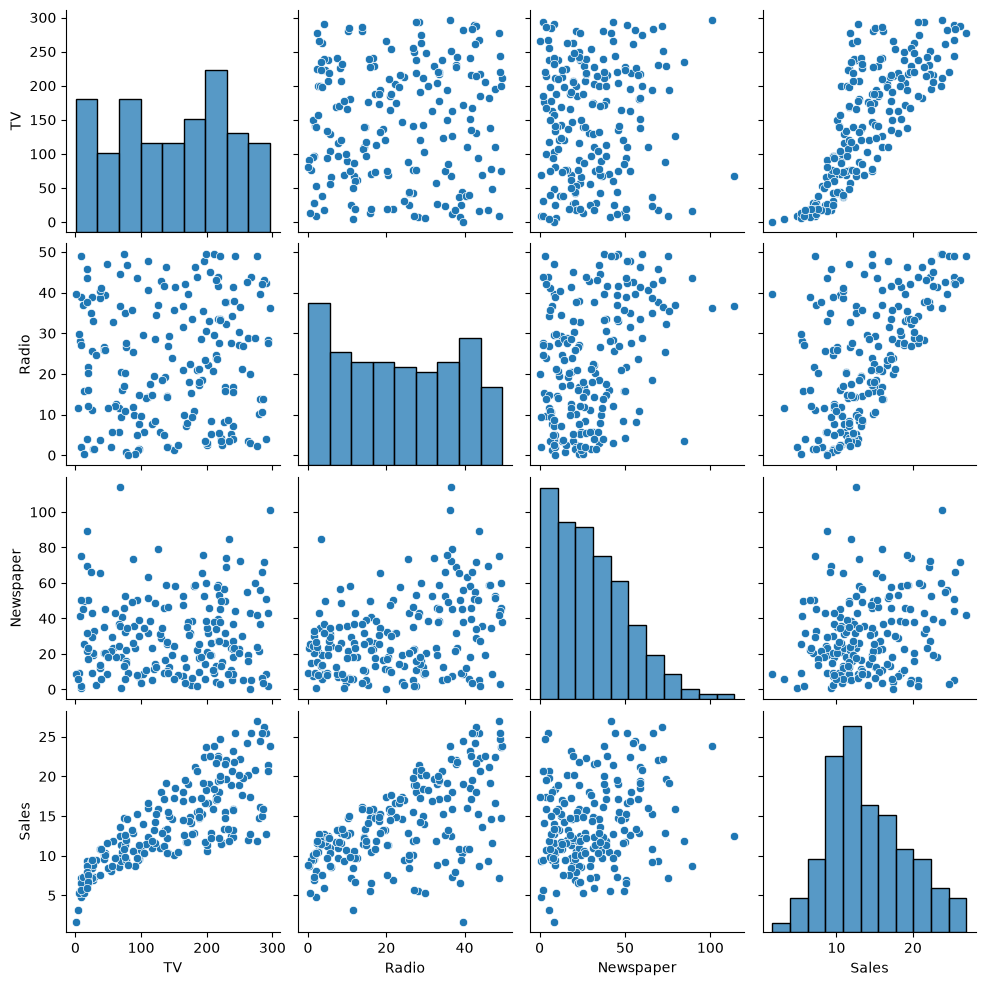

In [8]:
#  EXPLORATORY DATA ANALYSIS - PAIRPLOT
sns.pairplot(df)

plt.show()

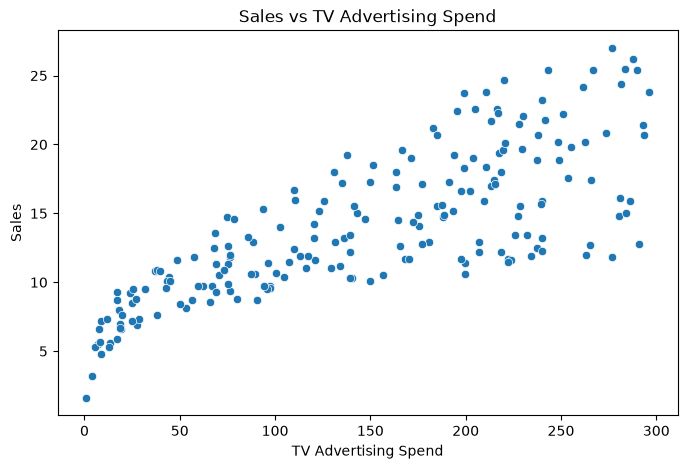

In [9]:
# SALES VS TV ADVERTISING
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales"
)

plt.title("Sales vs TV Advertising Spend")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

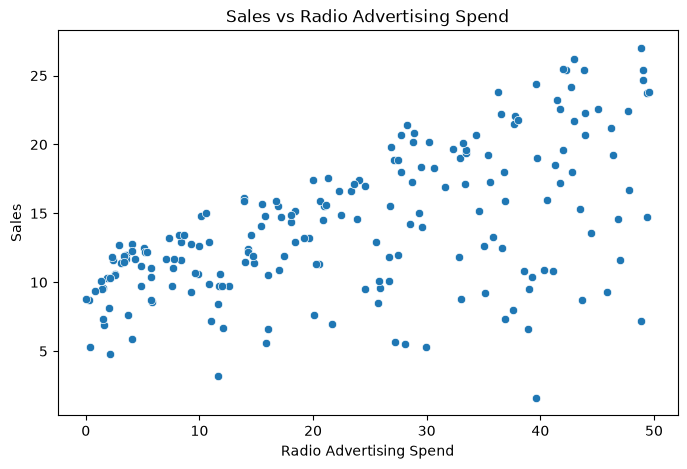

In [11]:
# SALES VS RADIO ADVERTISING
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Radio",
    y="Sales"
)

plt.title("Sales vs Radio Advertising Spend")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

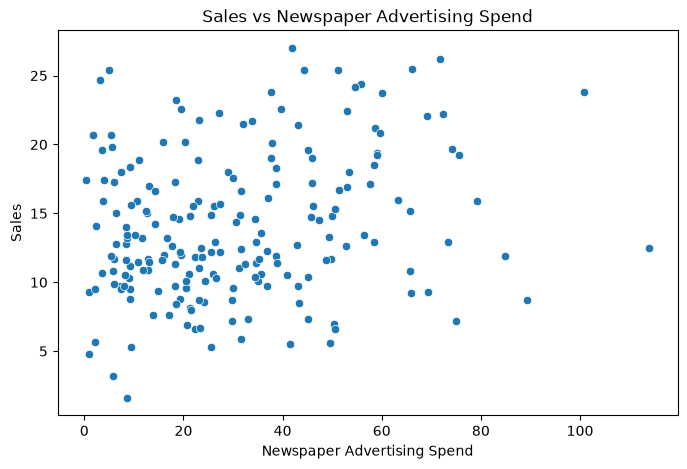

In [12]:
# SALES VS NEWSPAPER ADVERTISING
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Newspaper",
    y="Sales"
)

plt.title("Sales vs Newspaper Advertising Spend")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()

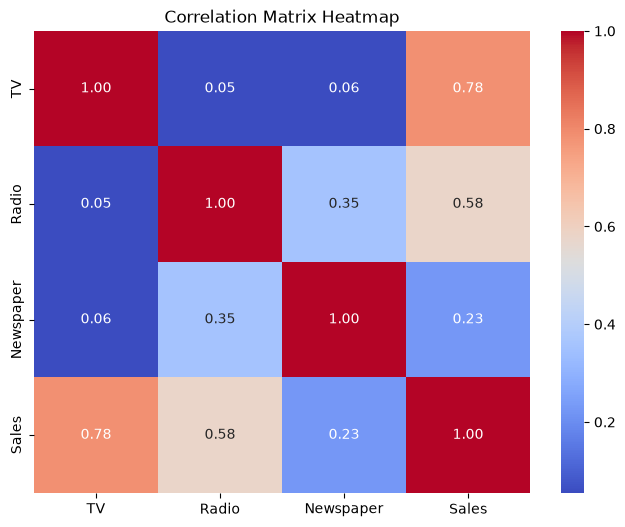

In [13]:
# CORRELATION MATRIX HEATMAP
correlation_matrix = df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix Heatmap")

plt.show()

In [14]:
#  DEFINE FEATURES AND TARGET

X = df[["TV", "Radio", "Newspaper"]]

y = df["Sales"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Sales")

Features:
['TV', 'Radio', 'Newspaper']

Target:
Sales


In [15]:
#  TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (160, 3)
Testing data shape: (40, 3)


In [16]:
# LINEAR REGRESSION MODEL

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [17]:
# EVALUATE LINEAR REGRESSION
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE      :", linear_mae)
print("RMSE     :", linear_rmse)
print("R² Score :", linear_r2)

Linear Regression Performance
--------------------------------
MAE      : 1.4607567168117606
RMSE     : 1.7815996615334502
R² Score : 0.899438024100912


In [18]:
# RANDOM FOREST REGRESSOR
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


In [19]:
# EVALUATE RANDOM FOREST
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Regressor Performance")
print("-------------------------------------")
print("MAE      :", rf_mae)
print("RMSE     :", rf_rmse)
print("R² Score :", rf_r2)

Random Forest Regressor Performance
-------------------------------------
MAE      : 0.6203249999999988
RMSE     : 0.7687170968568338
R² Score : 0.9812782416450916


In [20]:
# MODEL PERFORMANCE COMPARISON
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R² Score": [
        linear_r2,
        rf_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest Regressor,0.620325,0.768717,0.981278


In [21]:
# IDENTIFY BEST-PERFORMING MODEL
if rf_r2 > linear_r2:
    best_model = "Random Forest Regressor"
    best_predictions = rf_predictions
else:
    best_model = "Linear Regression"
    best_predictions = linear_predictions

print("Best Performing Model:", best_model)

Best Performing Model: Random Forest Regressor


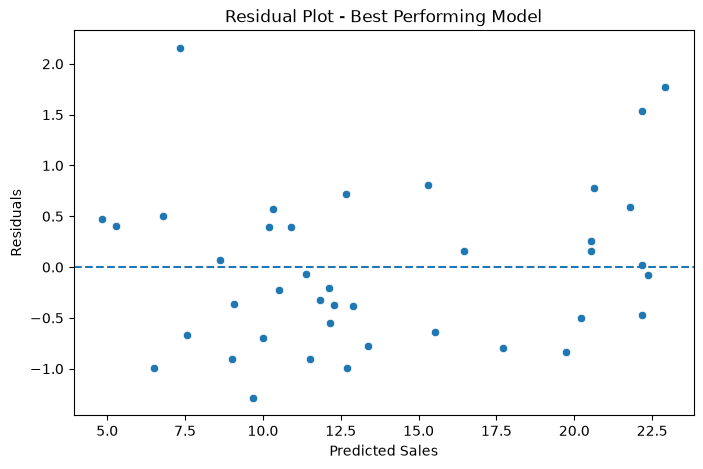

In [22]:
# RESIDUAL PLOT FOR BEST MODEL
residuals = y_test - best_predictions

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot - Best Performing Model")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.show()

In [23]:
# ADVERTISING CHANNEL IMPACT
coefficients = pd.DataFrame({
    "Advertising Channel": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Advertising Channel,Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761


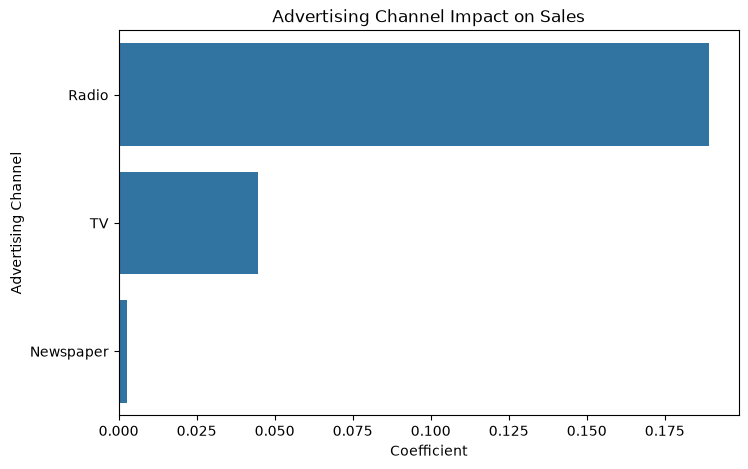

In [24]:
# ADVERTISING CHANNEL IMPACT CHART
plt.figure(figsize=(8, 5))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Advertising Channel"
)

plt.title("Advertising Channel Impact on Sales")
plt.xlabel("Coefficient")
plt.ylabel("Advertising Channel")

plt.show()

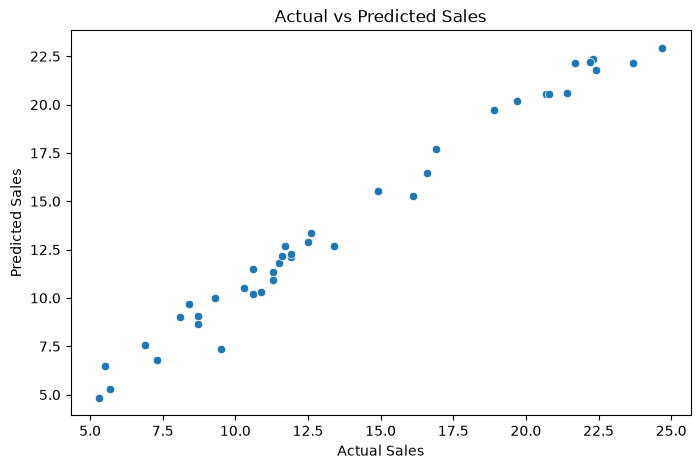

In [25]:
#  ACTUAL VS PREDICTED SALES
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test,
    y=best_predictions
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [26]:
# FINAL MODEL RESULTS
print("======================================")
print("       FINAL PROJECT RESULTS")
print("======================================")

print("Best Performing Model:", best_model)

if best_model == "Random Forest Regressor":
    print("MAE      :", rf_mae)
    print("RMSE     :", rf_rmse)
    print("R² Score :", rf_r2)
else:
    print("MAE      :", linear_mae)
    print("RMSE     :", linear_rmse)
    print("R² Score :", linear_r2)

highest_impact_channel = coefficients.iloc[0]["Advertising Channel"]

print("Highest Impact Advertising Channel:",
      highest_impact_channel)

       FINAL PROJECT RESULTS
Best Performing Model: Random Forest Regressor
MAE      : 0.6203249999999988
RMSE     : 0.7687170968568338
R² Score : 0.9812782416450916
Highest Impact Advertising Channel: Radio


# Final Conclusion

The Sales Prediction project was successfully completed using Machine Learning regression techniques.

Two regression models were trained and evaluated:

- Linear Regression
- Random Forest Regressor

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

Based on the evaluation results, the **Random Forest Regressor** achieved the best overall performance and was selected as the final model for sales prediction.

A residual plot was created to analyze the prediction errors of the best-performing model and understand whether the errors were randomly distributed.

The impact of different advertising channels, including TV, Radio, and Newspaper, was also analyzed using Linear Regression coefficients to identify the channel with the highest influence on sales.

Overall, this project demonstrates an end-to-end Machine Learning workflow including data loading, data cleaning, exploratory data analysis, data visualization, model training, model comparison, evaluation, residual analysis, and result interpretation.

The project provided practical experience in applying regression techniques to real-world sales prediction problems.